# Part 4 — Vector Databases
## Task 4.1 — Embedding & Similarity
**Model:** all-MiniLM-L6-v2 via sentence-transformers

In [1]:
# Step 1 — Install required library
!pip install sentence-transformers

In [2]:
# Step 2 — Import libraries
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('All libraries imported successfully!')

All libraries imported successfully!


In [3]:
# Step 3 — Define 10 sentences across 3 topics
sentences = [
    # Cricket (4 sentences)
    'The batsman hit a six over long-on to win the match.',
    'India won the Test series after a brilliant bowling performance.',
    'The spinner took five wickets on a turning pitch.',
    'The fielder took a stunning catch at the boundary rope.',

    # Cooking (3 sentences)
    'Add the chopped onions to the pan and saute until golden brown.',
    'The biryani was slow-cooked with aromatic spices for two hours.',
    'Knead the dough well before rolling it out for chapatis.',

    # Cybersecurity (3 sentences)
    'The firewall blocked the unauthorized access attempt from an unknown IP.',
    'Always use two-factor authentication to secure your online accounts.',
    'The ransomware encrypted all files and demanded payment in cryptocurrency.'
]

labels = [
    'Cricket-1', 'Cricket-2', 'Cricket-3', 'Cricket-4',
    'Cooking-1', 'Cooking-2', 'Cooking-3',
    'Cyber-1',   'Cyber-2',   'Cyber-3'
]

print(f'Total sentences: {len(sentences)}')
for i, s in enumerate(sentences):
    print(f'{i+1}. [{labels[i]}] {s}')

Total sentences: 10
1. [Cricket-1] The batsman hit a six over long-on to win the match.
2. [Cricket-2] India won the Test series after a brilliant bowling performance.
3. [Cricket-3] The spinner took five wickets on a turning pitch.
4. [Cricket-4] The fielder took a stunning catch at the boundary rope.
5. [Cooking-1] Add the chopped onions to the pan and saute until golden brown.
6. [Cooking-2] The biryani was slow-cooked with aromatic spices for two hours.
7. [Cooking-3] Knead the dough well before rolling it out for chapatis.
8. [Cyber-1] The firewall blocked the unauthorized access attempt from an unknown IP.
9. [Cyber-2] Always use two-factor authentication to secure your online accounts.
10. [Cyber-3] The ransomware encrypted all files and demanded payment in cryptocurrency.


In [4]:
# Step 4 — Load model and generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print(f'Embeddings shape: {embeddings.shape}')
print(f'Each sentence is represented as a vector of {embeddings.shape[1]} dimensions')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings shape: (10, 384)
Each sentence is represented as a vector of 384 dimensions


In [5]:
# Step 5 — Compute 10x10 cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

print('10x10 Cosine Similarity Matrix:')
print(np.round(similarity_matrix, 2))

10x10 Cosine Similarity Matrix:
[[ 1.    0.51  0.56  0.39  0.04  0.1   0.1   0.04 -0.04  0.03]
 [ 0.51  1.    0.45  0.29  0.12  0.1   0.14  0.11 -0.03  0.07]
 [ 0.56  0.45  1.    0.33  0.13  0.16  0.23  0.02 -0.04  0.02]
 [ 0.39  0.29  0.33  1.   -0.    0.02  0.13  0.13 -0.04 -0.03]
 [ 0.04  0.12  0.13 -0.    1.    0.27  0.36  0.06 -0.01  0.01]
 [ 0.1   0.1   0.16  0.02  0.27  1.    0.22  0.11 -0.04  0.02]
 [ 0.1   0.14  0.23  0.13  0.36  0.22  1.   -0.01  0.05  0.1 ]
 [ 0.04  0.11  0.02  0.13  0.06  0.11 -0.01  1.    0.18  0.14]
 [-0.04 -0.03 -0.04 -0.04 -0.01 -0.04  0.05  0.18  1.    0.05]
 [ 0.03  0.07  0.02 -0.03  0.01  0.02  0.1   0.14  0.05  1.  ]]


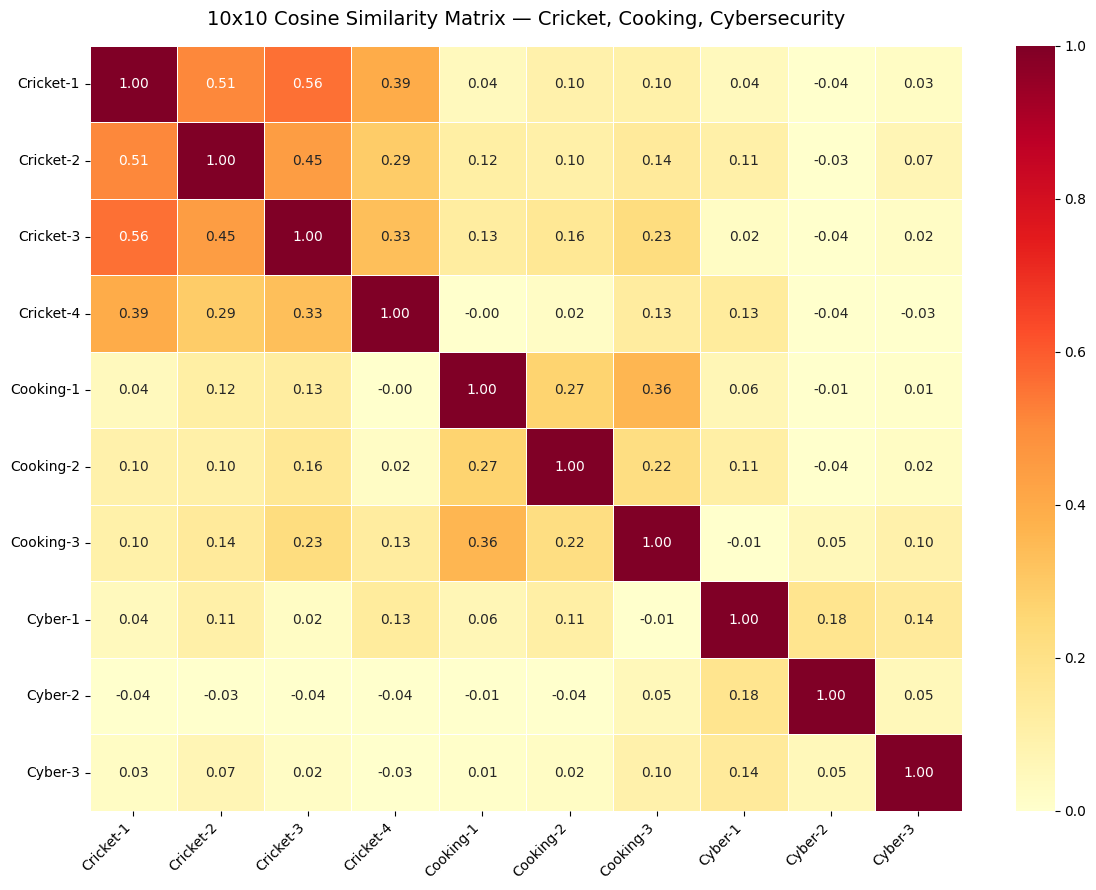

Heatmap displayed!


In [6]:
# Step 6 — Display similarity matrix as a heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    similarity_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    linewidths=0.5
)
plt.title('10x10 Cosine Similarity Matrix — Cricket, Cooking, Cybersecurity', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print('Heatmap displayed!')

In [7]:
# Step 7 — Find top 2 most similar sentences to the query
query = 'The bowler took three wickets in one over'

# Generate embedding for query
query_embedding = model.encode([query])

# Compute similarity between query and all 10 sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Sort by similarity (descending)
ranked_indices = np.argsort(query_similarities)[::-1]

print(f'Query: "{query}"')
print()
print('Top 2 Most Similar Sentences:')
print('-' * 60)
for rank, idx in enumerate(ranked_indices[:2], 1):
    print(f'Rank {rank}: [{labels[idx]}]')
    print(f'  Sentence : {sentences[idx]}')
    print(f'  Similarity Score: {query_similarities[idx]:.4f}')
    print()

Query: "The bowler took three wickets in one over"

Top 2 Most Similar Sentences:
------------------------------------------------------------
Rank 1: [Cricket-3]
  Sentence : The spinner took five wickets on a turning pitch.
  Similarity Score: 0.6868

Rank 2: [Cricket-2]
  Sentence : India won the Test series after a brilliant bowling performance.
  Similarity Score: 0.6067

